# Programa de Capacitação de Processamento Digital de Sinais

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Desenvolvido por:
-   Elmer Pimentel Farias


# Filtros Adaptativos e Equalização de Canais

Filtros adaptativos são sistemas capazes de ajustar seus coeficientes automaticamente para minimizar um erro, adaptando-se a ambientes desconhecidos ou variantes no tempo. Diferente dos filtros fixos, eles operam em malha fechada, utilizando o erro entre a saída e um sinal desejado para atualizar seus pesos.



## Principais Algoritmos

* **LMS (Least Mean Squares):** O mais utilizado devido à sua simplicidade e baixo custo computacional. Baseia-se no gradiente estocástico para minimizar o erro quadrático médio.
    * **Equação de atualização:** $$\mathbf{w}(n+1) = \mathbf{w}(n) + \mu e(n) \mathbf{x}(n)$$
* **CMA (Constant Modulus Algorithm):** Essencial para **equalização cega** (sem sinal de referência), buscando restaurar o módulo constante de sinais modulados.
* **Outros (RLS, NLMS):** O **RLS** oferece convergência rápida com maior custo computacional, enquanto o **NLMS** normaliza o passo de adaptação para maior estabilidade.



## Livro-Texto Base

> **Adaptive Filtering: Algorithms and Practical Implementation (5ed)**
> *Paulo S. R. Diniz* 

Caps. 1, 2, 3 e 13

## Objetivos da Capacitação 

1.  **Implementação:** Codificar o algoritmo **LMS**.
2.  **Aplicação:** Realizar a **equalização de um canal passa-baixas**, visando mitigar a Interferência Intersimbólica (ISI).
3.  **Avaliação de Desempenho:**
    * Utilizar o **MSE (Mean Squared Error)** como métrica de convergência.
    * Analisar o impacto do **passo de adaptação ($\mu$)** (velocidade vs. erro residual).
    * Testar a robustez do sistema sob diferentes condições de **SNR**.



# O Algoritmo LMS (Least Mean Squares)

O diagrama de blocos acima ilustra a estrutura padrão de um filtro adaptativo. O algoritmo **LMS** atua dentro do bloco "Adaptive Algorithm", ajustando os coeficientes do filtro linear para minimizar o erro entre a saída do filtro e um sinal desejado.

![Texto Alternativo](images/lmsbasic.png)


Abaixo, descrevemos o funcionamento passo a passo com base nas variáveis ilustradas:

### 1. Definição das Variáveis

Com base no diagrama e na literatura do curso:

* $\mathbf{x}[k]$ : **Vetor de Entrada**. Contém a amostra atual e as amostras passadas do sinal de entrada (linha de atraso).
* $\mathbf{h}[k]$: **Vetor de Coeficientes**. Representa os pesos do filtro linear (FIR) no instante . O objetivo do LMS é encontrar os valores ótimos para este vetor.
* $\mathbf{y}[k]$: **Saída do Filtro**. É a estimativa do sinal desejado, calculada pela convolução (ou produto interno) entre a entrada e os coeficientes atuais.
* $\mathbf{d}[k]$: **Sinal Desejado** (ou Referência). É o sinal que o sistema tenta reproduzir ou identificar.
*$\mathbf{e}[k]$ : **Sinal de Erro**.  A diferença instantânea entre o que se deseja ($d[k]$) e o que o filtro entregou ($y[k]$).
### 2. O Ciclo de Funcionamento

O algoritmo opera em um ciclo contínuo de realimentação (feedback loop) composto por três etapas principais a cada iteração :

#### Passo 1: Filtragem (Cálculo da Saída)

O filtro linear processa o sinal de entrada $\mathbf{x}[k]$ com os coeficientes atuais $\mathbf{h}[k]$ para gerar a saída estimada:

$$y[k] = \mathbf{h}^T[k] \mathbf{x}[k]$$

#### Passo 2: Cálculo do Erro

O sistema compara a saída estimada $y[k]$ com o sinal desejado $d[k]$ através do somador (subtrator) mostrado no diagrama. Este erro guiará a adaptação:

$$e[k] = d[k] - y[k]$$


#### Passo 3: Atualização dos Pesos (Adaptive Algorithm)

Aqui entra o LMS. Ele utiliza o erro $e[k]$ para atualizar o vetor $\mathbf{h}[k]$, movendo-o na direção oposta ao gradiente do erro quadrático instantâneo. A equação de atualização é:

$$\mathbf{h}[k+1] = \mathbf{h}[k] + 2\mu e[k] \mathbf{x}[k]$$

Onde:

* :Onde:$\mathbf{h}[k+1]$: Novos coeficientes para a próxima iteração.
* $\mu$: Passo de adaptação (step-size). Controla a velocidade de convergência e a estabilidade do filtro.

### 3. Resumo do Algoritmo

O "segredo" do LMS é sua simplicidade computacional. Ao contrário do algoritmo de Wiener, que exige cálculos complexos de matrizes de correlação, o LMS usa o próprio erro instantâneo como uma estimativa estocástica do gradiente.

Para implementar em código, o laço de repetição segue esta lógica:

* 1- Recebe nova amostra $x[k]$ e $d[k]$.
* 2- Calcula $y[k]$.
* 3- Calcula $e[k]$.
* 4- Atualiza $\mathbf{h} \leftarrow \mathbf{h} + 2\mu e[k] \mathbf{x}[k]$.



### Bibliotecas Importadas

In [2]:
import sympy as sp
from sympy import latex
import numpy as np
from IPython.display import Math, Latex, display
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from scipy.signal import freqz
from numba import njit


# Objetivo: Equalização de Canal com Algoritmo LMS

Implementar e avaliar o desempenho do algoritmo **LMS (Least Mean Squares)** aplicado à equalização de um canal de comunicação.

![Texto Alternativo](images/equalilms.png)

### Estrutura do Sistema de Equalização

Baseado no diagrama acima, as variáveis do sistema são definidas como:
* $s[k]$ (Transmitted Signal): O sinal de informação original.
* Canal $H(z)$: Modela o meio de transmissão. Neste estudo, utilizamos um modelo passa-baixas
* $v[k]$ (Noise): Ruído aditivo (AWGN) somado ao sinal, simulando interferências térmicas ou do ambiente. O nível deste ruído define a SNR (Signal-to-Noise Ratio).
* $x[k]$ (Received Signal): O sinal distorcido e ruidoso que chega ao receptor. É a entrada do filtro adaptativo.


    $$x[k] = s[k] * h[k] + v[k]

* $$Delay $\Delta$: Um atraso proposital aplicado ao sinal desejado. Como o canal físico é causal, o equalizador precisa de um tempo de processamento para estimar o inverso do canal. Portanto, comparamos a saída do equalizador com uma versão atrasada do sinal original ($s[k-\Delta]$).$d[k]$.
* (Desired Signal): O sinal de referência para o treino do algoritmo, onde $d[k] = s[k-\Delta]$.
* $y[k]$ (Equalized Output): A tentativa do equalizador de reconstruir $d[k]$.


### Metodologia de Avaliação

O desempenho do equalizador será analisado através da curva de aprendizado e do erro em regime permanente, variando as seguintes condições:

1. **Passo de Adaptação ($\mu$):** Avaliaremos como diferentes valores de  influenciam a velocidade de convergência e a estabilidade do filtro. Espera-se um *trade-off*:  grande converge rápido mas com maior ruído residual (misadjustment);  pequeno é mais estável mas lento.
2. **Relação Sinal-Ruído (SNR):** Testaremos o sistema sob diferentes potências de ruído $v[k]$ . Isso determinará o "piso" de erro mínimo que o algoritmo consegue atingir (Erro de Wiener).

### Métrica de Desempenho: MSE

A principal métrica utilizada será o **Erro Quadrático Médio (MSE - Mean Squared Error)**. O algoritmo LMS busca minimizar a função custo instantânea $J[k] = |e[k]|^2$ .

A análise gráfica do MSE ao longo das iterações (curva de aprendizado) nos permitirá visualizar:

* O tempo necessário para o equalizador "abrir o olho" do diagrama de olho.
* O erro residual após a convergência.


In [3]:
@njit
def lms(x, d, Ntaps, mu):
    """
    Implementação do LMS alinhada com o diagrama de blocos fornecido.
    
    Mapeamento Diagrama -> Código:
    - Received Signal x[k]    -> x
    - Desired Signal d[k]     -> d
    - Equalized Output y[k]   -> y
    - Adaptive Filter w[k]    -> w
    - Error Signal e[k]       -> e
    """
    N = len(x)
    
    # 1. Alocação de Memória
    # 'w' representa o vetor de pesos do filtro (Adaptive Filter w[k])
    w = np.zeros(Ntaps) 
    
    # Matriz para salvar o histórico de w[k] ao longo do tempo
    W = np.zeros((N - Ntaps, Ntaps))
    
    squared_e = np.zeros(N)
    y = np.zeros(N) # Equalized Output y[k]
    
    # 2. Inicialização do Buffer
    # Buffer representa o vetor x[k] dentro da linha de atraso do filtro
    buffer = x[0:Ntaps][::-1].copy()
    
    # 3. Loop Principal (Iteração k)
    # k representa o índice de tempo discreto, conforme diagrama
    for k in range(Ntaps, N):
        
        # Atualização do vetor de entrada (regressor)
        buffer[1:] = buffer[:-1]
        buffer[0] = x[k] # Entrada x[k] atual

        # A. Filtragem: y[k] = w[k]^T * x[k]
        # Gera a "Equalized Output"
        y[k] = np.dot(w, buffer)

        # B. Cálculo do Erro: e[k] = d[k] - y[k]
        # Nó de soma no canto inferior direito do diagrama
        e = d[k] - y[k]

        # C. Atualização dos Pesos (LMS Algorithm)
        # Seta "Weight Update" subindo para o filtro
        w += mu * e * buffer 

        # D. Armazenamento
        squared_e[k] = e**2
        
        # Salva o histórico dos pesos W
        W[k - Ntaps, :] = w

    return y, w, squared_e, W

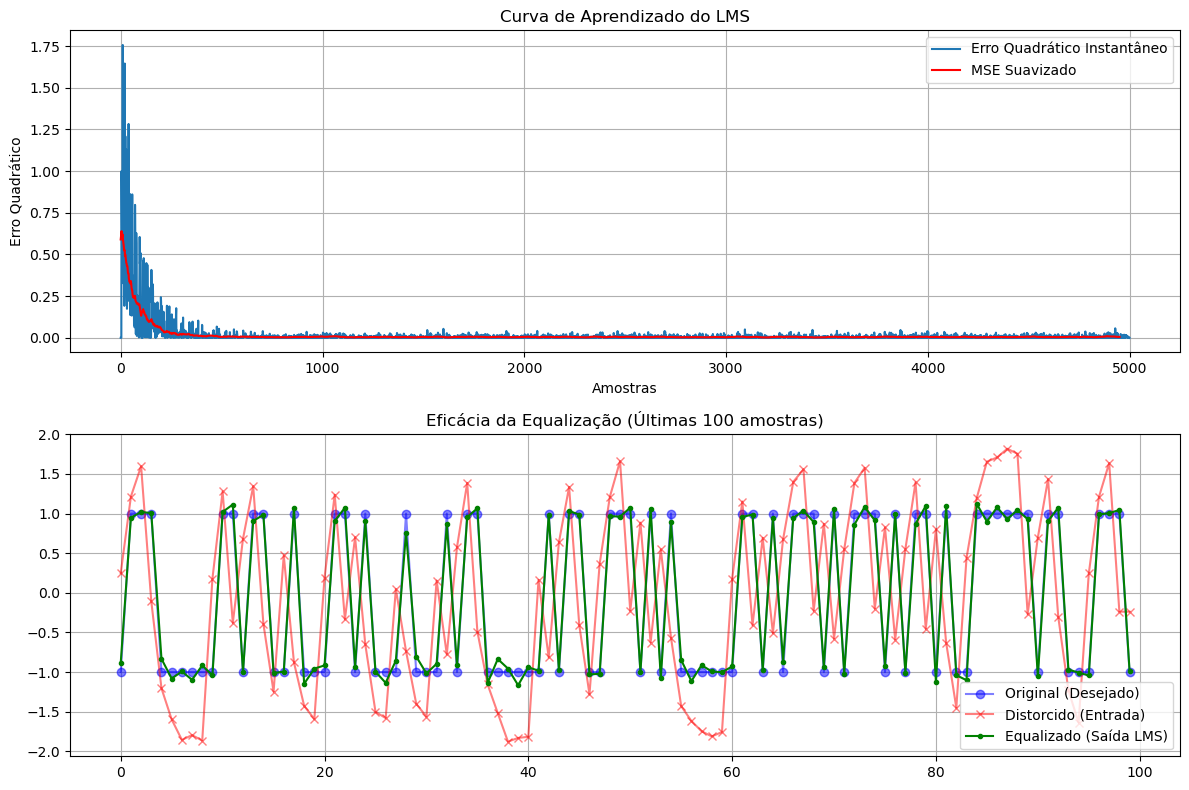

Coeficientes finais do filtro: 
[-5.47565698e-04  9.94930289e-01 -4.93009970e-01  4.80641638e-02]


In [4]:

# --- 2. Simulação do Cenário de Trabalho ---

# Parâmetros
N_samples = 5000
Ntaps = 4      # Ordem do equalizador
mu = 0.01       # Passo de adaptação (μ)

# A. Gerar o sinal original (Sinal Desejado 'd')
# Usaremos uma sequência binária (BPSK: -1 e 1)
d = np.sign(np.random.randn(N_samples))

# B. Simular o Canal Passa-Baixas (Distorção)
# Um canal simples que causa Interferência Intersimbólica (ISI)
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_puro = np.convolve(d, canal, mode='same')

# C. Adicionar um pouco de ruído branco (Realismo)
ruido = np.random.normal(0, 0.05, N_samples)
x = x_puro + ruido  # Este é o sinal distorcido que chega ao receptor

# --- 3. Execução da Equalização ---
# x: entrada distorcida
# d: sinal conhecido para treinamento
out, h_final, erro_quad, historico_h = lms(x, d, Ntaps, mu)

# --- 4. Visualização dos Resultados ---

plt.figure(figsize=(12, 8))

# Subplot 1: Curva de Aprendizado (MSE)
plt.subplot(2, 1, 1)
plt.plot(erro_quad, label='Erro Quadrático Instantâneo')
# Média móvel para suavizar a curva de erro
plt.plot(np.convolve(erro_quad, np.ones(50)/50, mode='valid'), label='MSE Suavizado', color='red')
plt.title('Curva de Aprendizado do LMS')
plt.xlabel('Amostras')
plt.ylabel('Erro Quadrático')
plt.legend()
plt.grid(True)

# Subplot 2: Comparação de Sinais (Zoom no final do sinal)
plt.subplot(2, 1, 2)
plt.plot(d[-100:], 'bo-', label='Original (Desejado)', alpha=0.5)
plt.plot(x[-100:], 'rx-', label='Distorcido (Entrada)', alpha=0.5)
plt.plot(out[-100:], 'g.-', label='Equalizado (Saída LMS)')
plt.title('Eficácia da Equalização (Últimas 100 amostras)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Coeficientes finais do filtro: \n{h_final}")

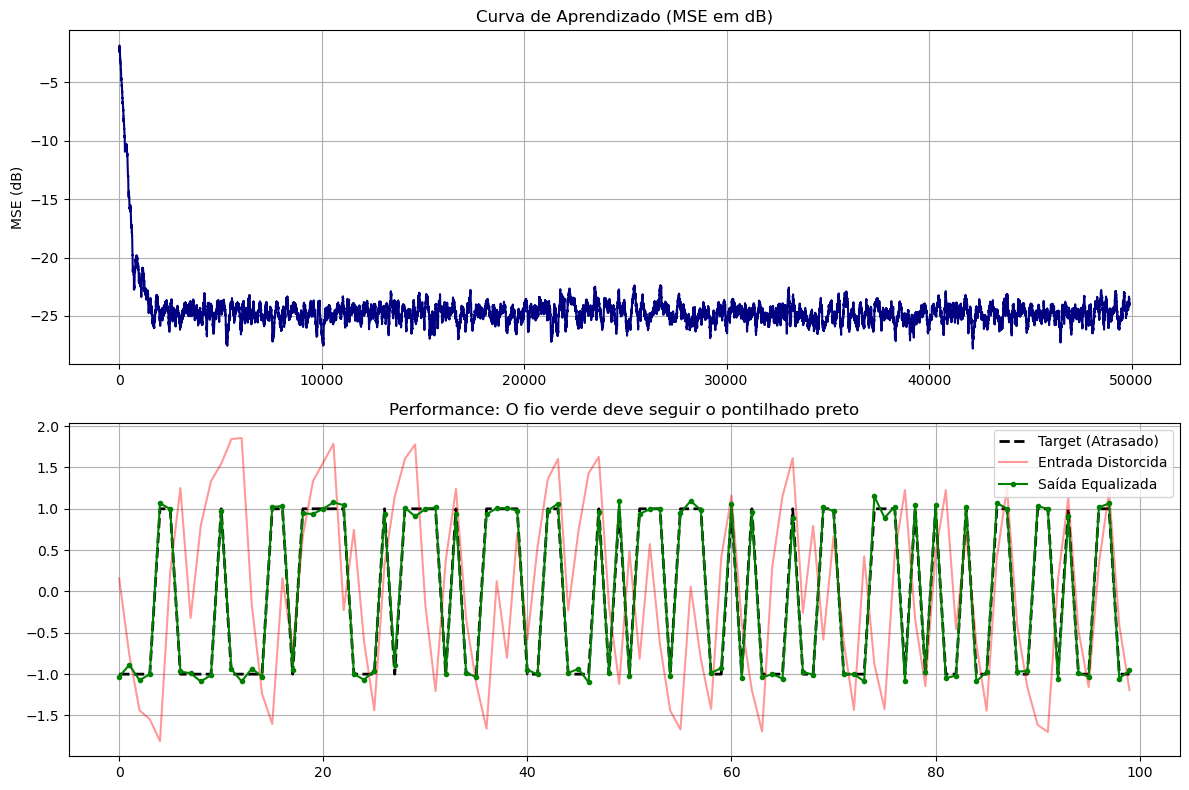

Canal Original: [1.  0.5 0.2 0.1]
Pesos do Equalizador (Primeiros 5): [ 0.    -0.001 -0.004  0.004 -0.006]


In [5]:
# --- SIMULAÇÃO ---

# Parâmetros
from scipy import signal


N_samples = 50000
# CORREÇÃO 2: Aumentar a ordem do filtro (4 é muito pouco para inverter esse canal)
Ntaps = 20      
mu = 0.005      
atraso = 10     # Delay para permitir causalidade

# A. Sinal
d_original = np.sign(np.random.randn(N_samples))

# B. Canal (Usando lfilter para simular sistema causal t=0)
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_sem_ruido = signal.lfilter(canal, 1, d_original)

# C. Ruído
x = x_sem_ruido + np.random.normal(0, 0.05, N_samples)

# D. CORREÇÃO 3: Sincronização (Delay)
# O equalizador tentará recuperar d[k - atraso]
d_treino = np.zeros(N_samples)
# O sinal desejado é o original atrasado
d_treino[atraso:] = d_original[:-atraso]

# --- Execução ---
out, h_final, erro_quad, historico_h = lms(x, d_treino, Ntaps, mu)

# --- Visualização ---
plt.figure(figsize=(12, 8))

# Gráfico 1: MSE
plt.subplot(2, 1, 1)
# Plotando em dB para ver melhor a queda
mse_db = 10 * np.log10(np.convolve(erro_quad, np.ones(100)/100, mode='valid') + 1e-12)
plt.plot(mse_db, color='navy')
plt.title('Curva de Aprendizado (MSE em dB)')
plt.ylabel('MSE (dB)')
plt.grid(True)

# Gráfico 2: Comparação Visual
# Vamos dar zoom no meio, onde já convergiu
zoom_start = 49000
zoom_end = 49100

plt.subplot(2, 1, 2)
# Sinal Desejado (O que queremos)
plt.plot(d_treino[zoom_start:zoom_end], 'k--', linewidth=2, label='Target (Atrasado)')
# Sinal Distorcido (O que chegou)
plt.plot(x[zoom_start:zoom_end], 'r-', alpha=0.4, label='Entrada Distorcida')
# Saída do Equalizador
plt.plot(out[zoom_start:zoom_end], 'g.-', linewidth=1.5, label='Saída Equalizada')

plt.title('Performance: O fio verde deve seguir o pontilhado preto')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Verificação dos coeficientes
print("Canal Original:", canal)
print("Pesos do Equalizador (Primeiros 5):", np.round(h_final[:5], 3))

In [14]:
import numpy as np
from scipy import signal
from scipy.linalg import toeplitz

# ==============================================================================
# 1. PREPARAÇÃO DO CENÁRIO (Sinais x e d)
# ==============================================================================
N_samples = 50000
Ntaps = 20      
mu = 0.001      
atraso = 10     

# Geração do sinal
d_original = np.sign(np.random.randn(N_samples))
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_sem_ruido = signal.lfilter(canal, 1, d_original)
x = x_sem_ruido + np.random.normal(0, 0.05, N_samples)

# Cria o sinal desejado com atraso (Sincronismo)
d_treino = np.zeros(N_samples)
d_treino[atraso:] = d_original[:-atraso]

# ==============================================================================
# 2. A CHAMADA DA SUA FUNÇÃO (AQUI ESTÁ ELA!)
# ==============================================================================
# É nesta linha abaixo que o seu código roda e devolve os coeficientes 'h_lms'
# ------------------------------------------------------------------------------
y_lms, h_lms, erro, historico = lms(x, d_treino, Ntaps, mu)
# ------------------------------------------------------------------------------


# ==============================================================================
# 3. CÁLCULO DA SOLUÇÃO TEÓRICA (WIENER) PARA COMPARAÇÃO
# ==============================================================================
def calcular_wiener_exato(x_in, d_ref, N_filtro):
    # Autocorrelação de x (Rxx)
    r_xx = np.correlate(x_in, x_in, mode='full')
    center = len(r_xx) // 2
    r_xx_vec = r_xx[center : center + N_filtro] / len(x_in)
    R_xx = toeplitz(r_xx_vec)
    
    # Correlação cruzada entre d e x (pdx)
    p_dx = np.zeros(N_filtro)
    for k in range(N_filtro):
        # Precisamos alinhar x[n-k] com d[n]
        val = np.mean(d_ref[k:] * x_in[:len(x_in)-k])
        p_dx[k] = val
        
    # Resolve w = inv(R)*p
    return np.linalg.solve(R_xx, p_dx)

w_wiener = calcular_wiener_exato(x, d_treino, Ntaps)

# ==============================================================================
# 4. TABELA COMPARATIVA (PRINT DA MATRIZ)
# ==============================================================================

print(f"{'TAP':^5} | {'LMS (Seu Código)':^18} | {'WIENER (Teórico)':^18} | {'DIFERENÇA':^12}")
print("-" * 60)

erro_total = 0
for k in range(Ntaps):
    val_lms = h_lms[k]
    val_wiener = w_wiener[k]
    diff = abs(val_lms - val_wiener)
    erro_total += diff
    
    # Formatação bonita dos números
    print(f"{k:02d}    | {val_lms: .6f}           | {val_wiener: .6f}           | {diff:.6f}")

print("-" * 60)
print(f"Erro Médio Absoluto (MAE): {erro_total/Ntaps:.8f}")

# Validação Rápida
if erro_total/Ntaps < 0.05:
    print("\n✅ SUCESSO: Seu LMS convergiu para a solução ótima!")
else:
    print("\n⚠️ ATENÇÃO: O LMS ainda está longe do ótimo. Tente aumentar N_samples ou ajustar mu.")

 TAP  |  LMS (Seu Código)  |  WIENER (Teórico)  |  DIFERENÇA  
------------------------------------------------------------
00    |  0.000661           | -0.000168           | 0.000829
01    | -0.000261           | -0.000027           | 0.000234
02    |  0.000872           |  0.000427           | 0.000444
03    |  0.001511           | -0.000416           | 0.001927
04    | -0.004202           | -0.000247           | 0.003954
05    |  0.001567           |  0.000477           | 0.001090
06    | -0.000842           | -0.000663           | 0.000180
07    |  0.001483           |  0.000397           | 0.001086
08    |  0.000308           | -0.000374           | 0.000682
09    |  0.001378           |  0.001211           | 0.000167
10    |  0.996050           |  0.996201           | 0.000151
11    | -0.497050           | -0.497232           | 0.000182
12    |  0.049247           |  0.049325           | 0.000079
13    | -0.023465           | -0.024656           | 0.001191
14    |  0.051245     

## Tabela de Trade-offs: Parâmetros do LMS

A escolha dos parâmetros do algoritmo LMS envolve um compromisso constante entre velocidade de convergência, precisão final (erro residual) e estabilidade.

| Parâmetro | Símbolo | Valor Alto (High) | Valor Baixo (Low) | Impacto Principal |
| :--- | :---: | :--- | :--- | :--- |
| **Passo de Adaptação** | $\mu$ (mu) | **Vantagem:** Convergência rápida (aprende depressa).<br>**Risco:** Erro residual alto (misadjustment), oscilação e possível instabilidade/divergência. | **Vantagem:** Alta precisão no estado estacionário (erro residual mínimo) e estabilidade robusta.<br>**Risco:** Convergência lenta (pode não acompanhar variações rápidas do sistema). | Controla o equilíbrio entre **Velocidade vs. Precisão**. |
| **Ordem do Filtro** | $N_{taps}$ | **Vantagem:** Melhor resolução espectral; capaz de modelar sistemas com respostas ao impulso longas (ecos distantes).<br>**Risco:** Maior custo computacional; convergência mais lenta; maior "ruído de gradiente". | **Vantagem:** Rápido processamento; menor variância na estimativa.<br>**Risco:** *Underfitting* (não consegue modelar a complexidade do sistema); performance pobre se o canal tiver memória longa. | Define a **Capacidade de Modelagem vs. Custo Computacional**. |
| **Número de Amostras** | $N$ | **Vantagem:** Garante que o filtro atinja o regime permanente (steady-state), mesmo com $\mu$ pequeno.<br>**Risco:** Maior tempo de processamento/simulação; latência na resposta. | **Vantagem:** Simulação rápida.<br>**Risco:** O filtro pode ser interrompido ainda na fase transiente (aprendizado incompleto). | Define a **Suficiência Estatística** para a convergência. |

1. O Passo de Adaptação ($\mu$)

O $\mu$ regula o tamanho do salto que damos na superfície de erro em direção ao mínimo global.
* Teoria: O LMS é uma aproximação estocástica do Steepest Descent. O erro em regime permanente (Steady-State Mean Square Error - MSE) é dado por:

    $$J(\infty) = J_{min} + \text{Excesso de MSE}$$

Onde o "Excesso de MSE" é proporcional a $\mu$.

* Conclusão: Um $\mu$ grande faz você descer a "montanha do erro" correndo (rápido), mas você nunca para quieto no fundo do vale (fica oscilando ao redor do ponto ótimo), gerando um ruído de fundo constante chamado Misadjustment. Um $\mu$ pequeno desce devagar, mas para exatamente no fundo.

2. O Número de Taps ($N_{taps}$)
Define a memória temporal do filtro. Se o sistema desconhecido (ex: um canal acústico ou um cabo) tem uma resposta ao impulso que dura $T$ segundos, e sua taxa de amostragem é $F_s$, o filtro precisa de no mínimo $N_{taps} \approx T \times F_s$ para "cobrir" esse efeito.

* Teoria (Complexidade): O LMS tem complexidade $O(N_{taps})$ por iteração. Dobrar os taps dobra o tempo de execução.

* Teoria (Ruído): Quanto mais coeficientes você tem para estimar, mais "ruído" entra no cálculo do gradiente estimado, especialmente se o sinal de entrada não for rico em frequências (excitação persistente). Usar taps demais desnecessariamente piora a performance.


3. Quantidade de Amostras ($N$ ou Samples)

Este parâmetro é uma consequência da escolha do $\mu$. O LMS tem uma constante de tempo de aprendizado ($\tau_{mse}$), que é inversamente proporcional a $\mu$.

* Relação:$$\tau_{mse} \approx \frac{1}{4 \mu \lambda_{avg}}$$
(Onde $\lambda_{avg}$ é a média dos autovalores da correlação do sinal).

* Na prática: Se você diminui o $\mu$ pela metade para ganhar precisão, você precisará (grosso modo) do dobro de amostras ($N$) para que o filtro chegue no mesmo ponto de aprendizado.